# Лабораторная работа №3
## Проведение исследований с решающим деревом

Цель работы — исследовать применение решающего дерева к задачам классификации и регрессии, построить базовые модели, улучшить их качество за счет проверки гипотез, реализовать собственные версии алгоритмов и сравнить результаты с реализациями из библиотеки scikit-learn.


## Выбор наборов данных

Для задачи классификации используется датасет Breast Cancer Wisconsin Diagnostic. Для задачи регрессии используется датасет Concrete Compressive Strength.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree


## Загрузка данных


In [2]:
columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df_cls = pd.read_csv("data/breast_cancer/wdbc.data", header=None, names=columns)
df_reg = pd.read_excel("data/concrete/concrete.xls")


In [3]:
print("Classification shape:", df_cls.shape)
print("Regression shape:", df_reg.shape)
display(df_cls.head())
display(df_reg.head())


Classification shape: (569, 32)
Regression shape: (1030, 9)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


## Первичный анализ данных


In [4]:
df_cls.info()
df_reg.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [5]:
display(df_cls.isna().sum())
display(df_reg.isna().sum())


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

In [6]:
display(df_cls.describe())
display(df_reg.describe())


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


## Выбор целевых переменных и метрик качества

Для классификации используются accuracy и F1-score. Для регрессии используются MAE, MSE и R2.


In [7]:
X_cls = df_cls.drop(columns=["id", "diagnosis"])
y_cls = df_cls["diagnosis"]

encoder = LabelEncoder()
y_cls = encoder.fit_transform(y_cls)

X_reg = df_reg.iloc[:, :-1]
y_reg = df_reg.iloc[:, -1]

print(X_cls.shape, len(y_cls))
print(X_reg.shape, len(y_reg))
print(encoder.classes_)


(569, 30) 569
(1030, 8) 1030
['B' 'M']


## Разделение данных на обучающую и тестовую выборки


In [8]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


## Построение базового решения на sklearn

На данном этапе строятся базовые модели решающего дерева для классификации и регрессии.


In [9]:
tree_cls_base = DecisionTreeClassifier(random_state=42)
tree_cls_base.fit(X_train_cls, y_train_cls)
y_pred_cls_base = tree_cls_base.predict(X_test_cls)

acc_base = accuracy_score(y_test_cls, y_pred_cls_base)
f1_base = f1_score(y_test_cls, y_pred_cls_base)

print("Baseline classification accuracy:", acc_base)
print("Baseline classification f1:", f1_base)


Baseline classification accuracy: 0.9298245614035088
Baseline classification f1: 0.9047619047619048


In [10]:
print(classification_report(y_test_cls, y_pred_cls_base))
print(confusion_matrix(y_test_cls, y_pred_cls_base))


              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

[[68  4]
 [ 4 38]]


In [11]:
tree_reg_base = DecisionTreeRegressor(random_state=42)
tree_reg_base.fit(X_train_reg, y_train_reg)
y_pred_reg_base = tree_reg_base.predict(X_test_reg)

mae_base = mean_absolute_error(y_test_reg, y_pred_reg_base)
mse_base = mean_squared_error(y_test_reg, y_pred_reg_base)
r2_base = r2_score(y_test_reg, y_pred_reg_base)

print("Baseline regression MAE:", mae_base)
print("Baseline regression MSE:", mse_base)
print("Baseline regression R2:", r2_base)


Baseline regression MAE: 4.5912651509848175
Baseline regression MSE: 53.673239708459036
Baseline regression R2: 0.7917067173788096


## Формулировка гипотез улучшения

1. Ограничение глубины дерева может уменьшить переобучение.
2. Изменение параметров min_samples_split и min_samples_leaf влияет на качество модели.
3. Выбор критерия разбиения влияет на качество классификации и регрессии.
4. Подбор гиперпараметров на кросс-валидации позволяет получить более качественное решение.
5. Анализ важности признаков позволяет лучше интерпретировать модель.


## Проверка гипотезы о влиянии глубины дерева


In [12]:
depth_values = list(range(1, 16))

cls_depth_scores = []
for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_cls, y_train_cls)
    pred = model.predict(X_test_cls)
    cls_depth_scores.append(f1_score(y_test_cls, pred))

reg_depth_scores = []
for depth in depth_values:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train_reg, y_train_reg)
    pred = model.predict(X_test_reg)
    reg_depth_scores.append(r2_score(y_test_reg, pred))


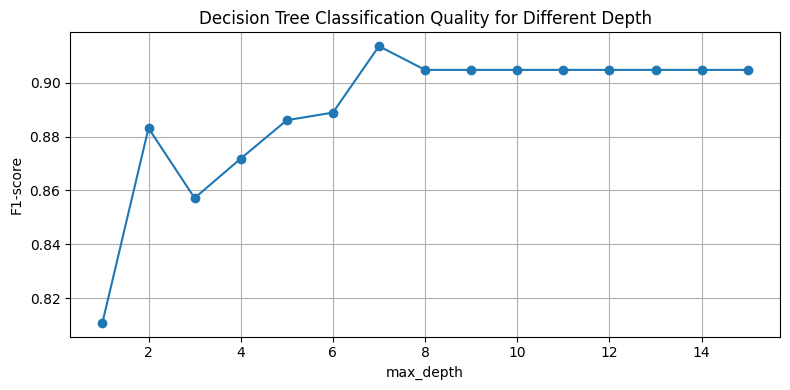

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(depth_values, cls_depth_scores, marker='o')
plt.xlabel("max_depth")
plt.ylabel("F1-score")
plt.title("Decision Tree Classification Quality for Different Depth")
plt.grid(True)
plt.tight_layout()
plt.show()


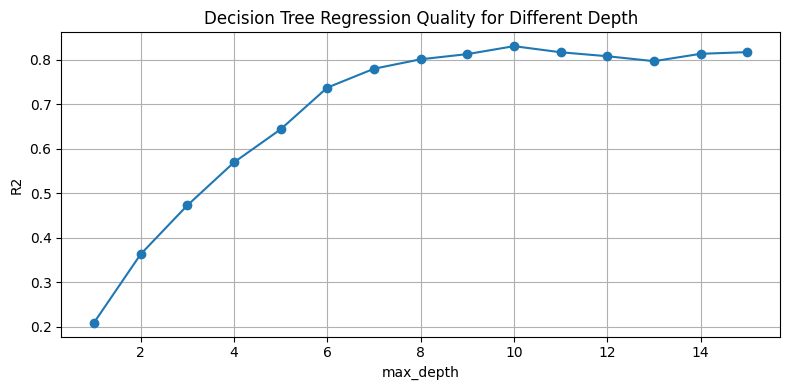

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(depth_values, reg_depth_scores, marker='o')
plt.xlabel("max_depth")
plt.ylabel("R2")
plt.title("Decision Tree Regression Quality for Different Depth")
plt.grid(True)
plt.tight_layout()
plt.show()


## Подбор гиперпараметров на кросс-валидации


In [15]:
param_grid_cls = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}

grid_cls = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_cls,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_cls.fit(X_train_cls, y_train_cls)

print(grid_cls.best_params_)
print(grid_cls.best_score_)


{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}
0.9328896983842206


In [16]:
param_grid_reg = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}

grid_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_reg,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_reg.fit(X_train_reg, y_train_reg)

print(grid_reg.best_params_)
print(grid_reg.best_score_)


{'criterion': 'friedman_mse', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.8234134568415037


## Формирование улучшенного baseline


In [17]:
tree_cls_improved = grid_cls.best_estimator_
tree_cls_improved.fit(X_train_cls, y_train_cls)
y_pred_cls_improved = tree_cls_improved.predict(X_test_cls)

acc_improved = accuracy_score(y_test_cls, y_pred_cls_improved)
f1_improved = f1_score(y_test_cls, y_pred_cls_improved)

print("Improved classification accuracy:", acc_improved)
print("Improved classification f1:", f1_improved)


Improved classification accuracy: 0.9385964912280702
Improved classification f1: 0.9090909090909091


In [18]:
tree_reg_improved = grid_reg.best_estimator_
tree_reg_improved.fit(X_train_reg, y_train_reg)
y_pred_reg_improved = tree_reg_improved.predict(X_test_reg)

mae_improved = mean_absolute_error(y_test_reg, y_pred_reg_improved)
mse_improved = mean_squared_error(y_test_reg, y_pred_reg_improved)
r2_improved = r2_score(y_test_reg, y_pred_reg_improved)

print("Improved regression MAE:", mae_improved)
print("Improved regression MSE:", mse_improved)
print("Improved regression R2:", r2_improved)


Improved regression MAE: 4.493081760402292
Improved regression MSE: 48.0168235423355
Improved regression R2: 0.8136579447970373


## Визуализация результатов улучшенного baseline


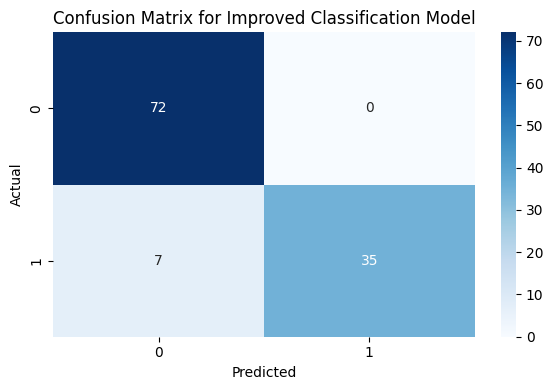

In [19]:
cm = confusion_matrix(y_test_cls, y_pred_cls_improved)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Improved Classification Model")
plt.tight_layout()
plt.show()


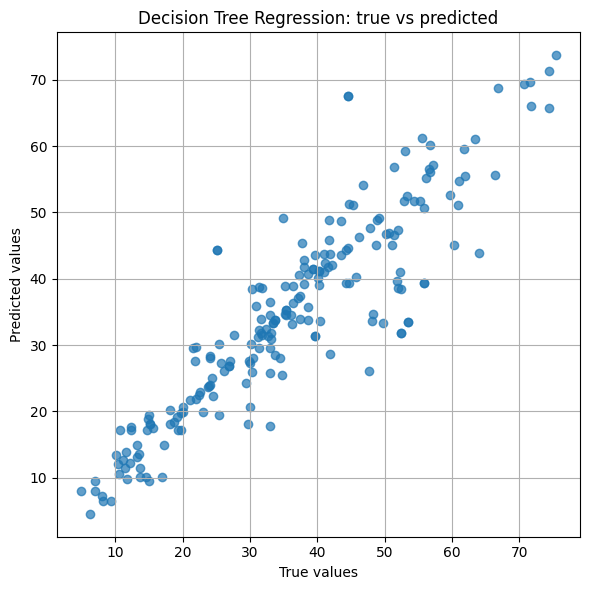

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg_improved, alpha=0.7)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Decision Tree Regression: true vs predicted")
plt.grid(True)
plt.tight_layout()
plt.show()


## Важность признаков


In [21]:
feature_importance_cls = pd.Series(tree_cls_improved.feature_importances_, index=X_cls.columns).sort_values(ascending=False).head(10)
feature_importance_reg = pd.Series(tree_reg_improved.feature_importances_, index=X_reg.columns).sort_values(ascending=False).head(10)

display(feature_importance_cls)
display(feature_importance_reg)


perimeter_worst         0.654875
concave_points_worst    0.116101
concave_points_mean     0.081728
texture_worst           0.068012
area_se                 0.046713
compactness_se          0.016409
concave_points_se       0.011641
concavity_mean          0.004521
symmetry_worst          0.000000
concavity_worst         0.000000
dtype: float64

Cement (component 1)(kg in a m^3 mixture)                0.360681
Age (day)                                                0.318937
Water  (component 4)(kg in a m^3 mixture)                0.144331
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0.072961
Fine Aggregate (component 7)(kg in a m^3 mixture)        0.044271
Fly Ash (component 3)(kg in a m^3 mixture)               0.024364
Superplasticizer (component 5)(kg in a m^3 mixture)      0.023076
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0.011378
dtype: float64

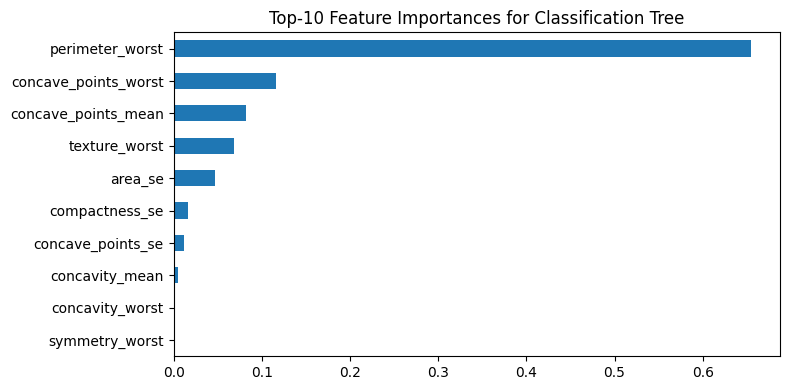

In [22]:
plt.figure(figsize=(8, 4))
feature_importance_cls.sort_values().plot(kind="barh")
plt.title("Top-10 Feature Importances for Classification Tree")
plt.tight_layout()
plt.show()


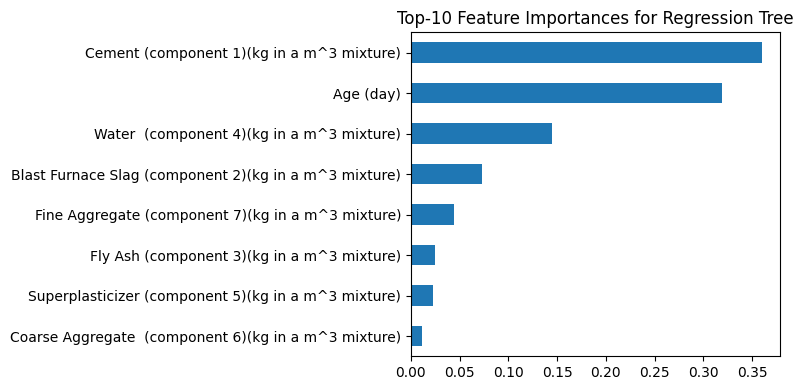

In [23]:
plt.figure(figsize=(8, 4))
feature_importance_reg.sort_values().plot(kind="barh")
plt.title("Top-10 Feature Importances for Regression Tree")
plt.tight_layout()
plt.show()


## Визуализация структуры дерева


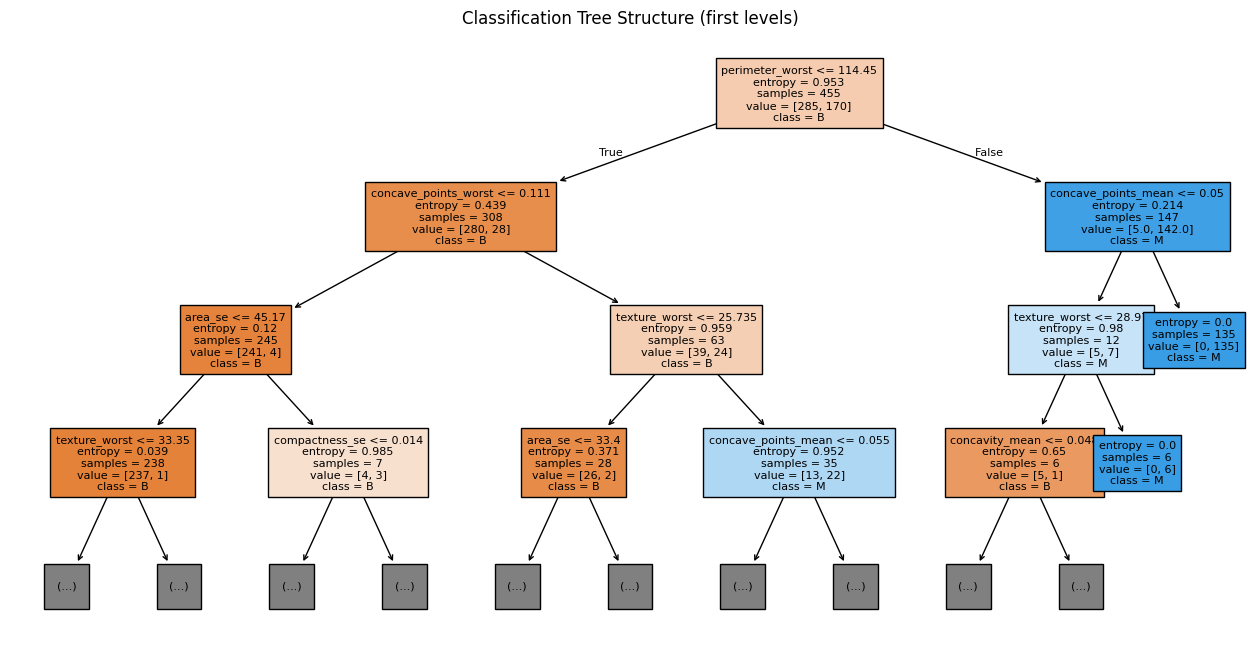

In [24]:
plt.figure(figsize=(16, 8))
plot_tree(tree_cls_improved, max_depth=3, feature_names=X_cls.columns, class_names=["B", "M"], filled=True, fontsize=8)
plt.title("Classification Tree Structure (first levels)")
plt.show()


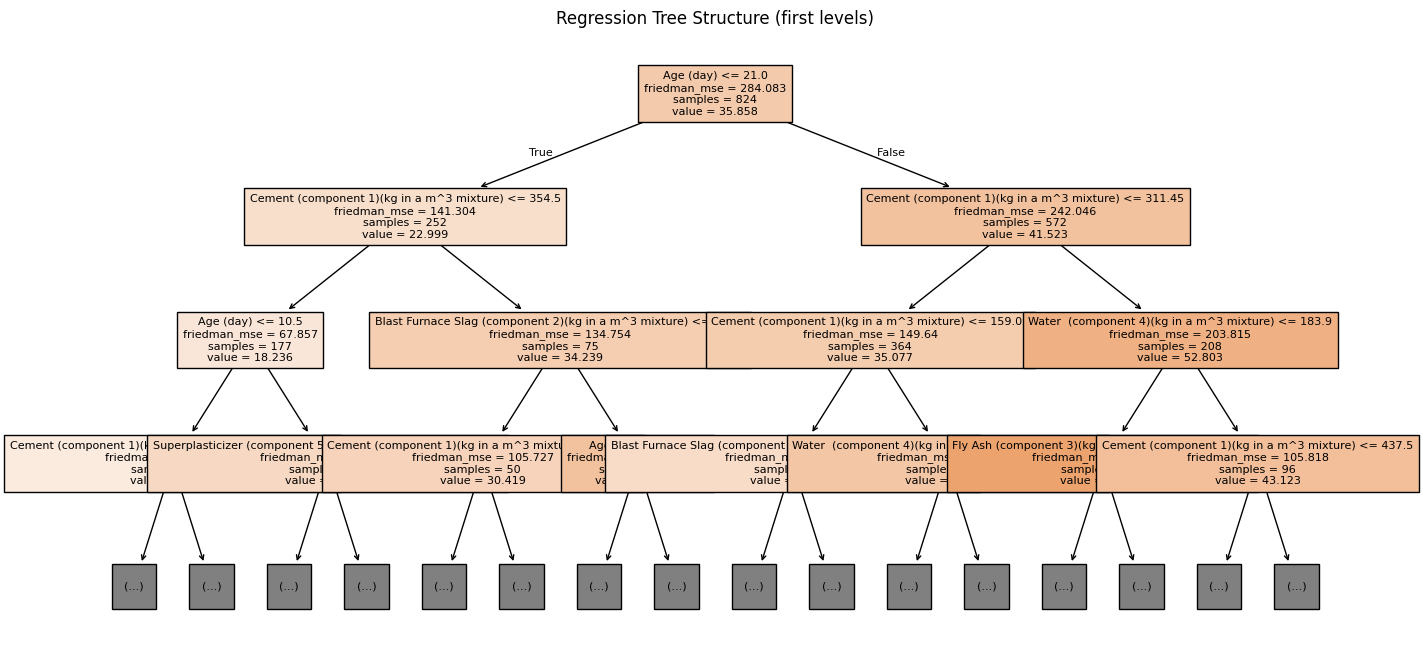

In [25]:
plt.figure(figsize=(16, 8))
plot_tree(tree_reg_improved, max_depth=3, feature_names=X_reg.columns, filled=True, fontsize=8)
plt.title("Regression Tree Structure (first levels)")
plt.show()


## Сравнение baseline и improved baseline


In [26]:
comparison_cls = pd.DataFrame({
    "Model": ["Baseline", "Improved baseline"],
    "Accuracy": [acc_base, acc_improved],
    "F1-score": [f1_base, f1_improved]
})

comparison_reg = pd.DataFrame({
    "Model": ["Baseline", "Improved baseline"],
    "MAE": [mae_base, mae_improved],
    "MSE": [mse_base, mse_improved],
    "R2": [r2_base, r2_improved]
})

display(comparison_cls)
display(comparison_reg)


,Model,Accuracy,F1-score
0,Baseline,0.929825,0.904762
1,Improved baseline,0.938596,0.909091


,Model,MAE,MSE,R2
0,Baseline,4.591265,53.673240,0.791707
1,Improved baseline,4.493082,48.016824,0.813658


## Графическое сравнение baseline и improved baseline


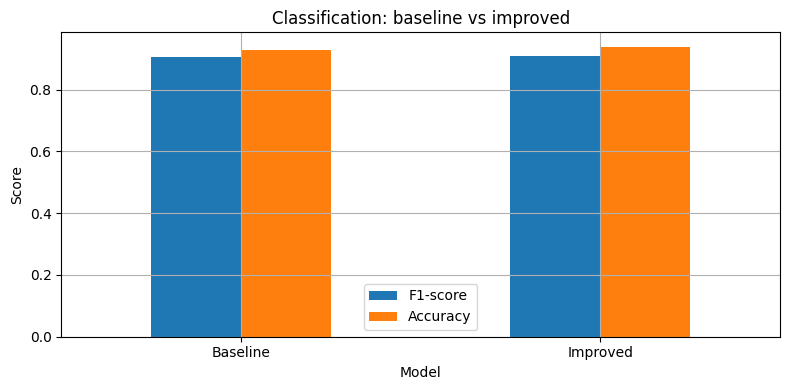

In [27]:
comparison_cls_plot = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "F1-score": [f1_base, f1_improved],
    "Accuracy": [acc_base, acc_improved]
})

comparison_cls_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Classification: baseline vs improved")
plt.ylabel("Score")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


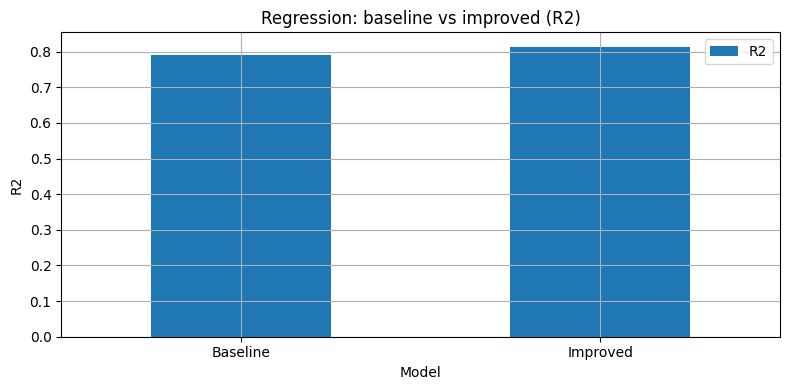

In [28]:
comparison_reg_r2_plot = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "R2": [r2_base, r2_improved]
})

comparison_reg_r2_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: baseline vs improved (R2)")
plt.ylabel("R2")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


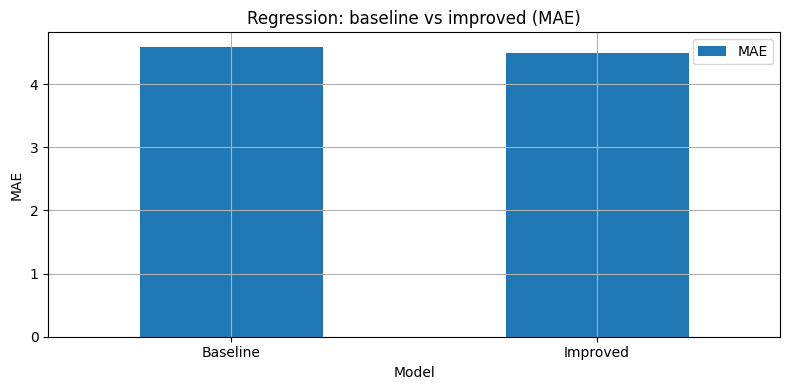

In [29]:
comparison_reg_mae_plot = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "MAE": [mae_base, mae_improved]
})

comparison_reg_mae_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: baseline vs improved (MAE)")
plt.ylabel("MAE")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Самостоятельная имплементация алгоритмов

Далее реализуются собственные версии решающего дерева для классификации и регрессии.


In [30]:
class MyDecisionTreeClassifier:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.n_classes_ = len(np.unique(y))
        self.n_features_ = X.shape[1]
        self.tree = self._grow_tree(X, y, depth=0)

    def predict(self, X):
        X = np.array(X)
        return np.array([self._traverse_tree(x, self.tree) for x in X])

    def _gini(self, y):
        m = len(y)
        if m == 0:
            return 0
        probs = [np.sum(y == c) / m for c in np.unique(y)]
        return 1 - sum(p ** 2 for p in probs)

    def _best_split(self, X, y):
        best_feature, best_threshold, best_gain = None, None, -1
        parent_impurity = self._gini(y)

        for feature_idx in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = X[:, feature_idx] > threshold
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                n = len(y)
                n_left, n_right = np.sum(left_mask), np.sum(right_mask)
                impurity = (n_left / n) * self._gini(y[left_mask]) + (n_right / n) * self._gini(y[right_mask])
                gain = parent_impurity - impurity

                if gain > best_gain:
                    best_feature, best_threshold, best_gain = feature_idx, threshold, gain

        return best_feature, best_threshold

    def _grow_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        if depth >= self.max_depth or num_labels == 1 or num_samples < self.min_samples_split:
            values, counts = np.unique(y, return_counts=True)
            return values[np.argmax(counts)]

        feature_idx, threshold = self._best_split(X, y)
        if feature_idx is None:
            values, counts = np.unique(y, return_counts=True)
            return values[np.argmax(counts)]

        left_mask = X[:, feature_idx] <= threshold
        right_mask = X[:, feature_idx] > threshold

        left_subtree = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

        return {"feature_idx": feature_idx, "threshold": threshold, "left": left_subtree, "right": right_subtree}

    def _traverse_tree(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node["feature_idx"]] <= node["threshold"]:
            return self._traverse_tree(x, node["left"])
        return self._traverse_tree(x, node["right"])


In [31]:
class MyDecisionTreeRegressor:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.tree = self._grow_tree(X, y, depth=0)

    def predict(self, X):
        X = np.array(X)
        return np.array([self._traverse_tree(x, self.tree) for x in X])

    def _mse(self, y):
        if len(y) == 0:
            return 0
        return np.mean((y - np.mean(y)) ** 2)

    def _best_split(self, X, y):
        best_feature, best_threshold, best_gain = None, None, -1
        parent_error = self._mse(y)

        for feature_idx in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = X[:, feature_idx] > threshold
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                n = len(y)
                n_left, n_right = np.sum(left_mask), np.sum(right_mask)
                error = (n_left / n) * self._mse(y[left_mask]) + (n_right / n) * self._mse(y[right_mask])
                gain = parent_error - error

                if gain > best_gain:
                    best_feature, best_threshold, best_gain = feature_idx, threshold, gain

        return best_feature, best_threshold

    def _grow_tree(self, X, y, depth):
        num_samples = X.shape[0]

        if depth >= self.max_depth or num_samples < self.min_samples_split or len(np.unique(y)) == 1:
            return np.mean(y)

        feature_idx, threshold = self._best_split(X, y)
        if feature_idx is None:
            return np.mean(y)

        left_mask = X[:, feature_idx] <= threshold
        right_mask = X[:, feature_idx] > threshold

        left_subtree = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

        return {"feature_idx": feature_idx, "threshold": threshold, "left": left_subtree, "right": right_subtree}

    def _traverse_tree(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node["feature_idx"]] <= node["threshold"]:
            return self._traverse_tree(x, node["left"])
        return self._traverse_tree(x, node["right"])


## Обучение и оценка собственной реализации


In [32]:
my_tree_cls = MyDecisionTreeClassifier(max_depth=5, min_samples_split=2)
my_tree_cls.fit(X_train_cls, y_train_cls)
y_pred_my_cls = my_tree_cls.predict(X_test_cls)

my_acc = accuracy_score(y_test_cls, y_pred_my_cls)
my_f1 = f1_score(y_test_cls, y_pred_my_cls)

print("My decision tree classification accuracy:", my_acc)
print("My decision tree classification f1:", my_f1)


My decision tree classification accuracy: 0.9122807017543859
My decision tree classification f1: 0.8717948717948718


In [33]:
my_tree_reg = MyDecisionTreeRegressor(max_depth=5, min_samples_split=2)
my_tree_reg.fit(X_train_reg, y_train_reg)
y_pred_my_reg = my_tree_reg.predict(X_test_reg)

my_mae = mean_absolute_error(y_test_reg, y_pred_my_reg)
my_mse = mean_squared_error(y_test_reg, y_pred_my_reg)
my_r2 = r2_score(y_test_reg, y_pred_my_reg)

print("My decision tree regression MAE:", my_mae)
print("My decision tree regression MSE:", my_mse)
print("My decision tree regression R2:", my_r2)


My decision tree regression MAE: 7.336756038638627
My decision tree regression MSE: 90.55545576148536
My decision tree regression R2: 0.64857546810529


## Сравнение собственной реализации и sklearn baseline


In [34]:
comparison_impl_cls = pd.DataFrame({
    "Model": ["sklearn baseline", "my implementation"],
    "Accuracy": [acc_base, my_acc],
    "F1-score": [f1_base, my_f1]
})

comparison_impl_reg = pd.DataFrame({
    "Model": ["sklearn baseline", "my implementation"],
    "MAE": [mae_base, my_mae],
    "MSE": [mse_base, my_mse],
    "R2": [r2_base, my_r2]
})

display(comparison_impl_cls)
display(comparison_impl_reg)


,Model,Accuracy,F1-score
0,sklearn baseline,0.929825,0.904762
1,my implementation,0.912281,0.871795


,Model,MAE,MSE,R2
0,sklearn baseline,4.591265,53.673240,0.791707
1,my implementation,7.336756,90.555456,0.648575


## Добавление техник улучшенного baseline в собственную реализацию


In [35]:
best_depth_cls = grid_cls.best_params_["max_depth"]
best_min_samples_split_cls = grid_cls.best_params_["min_samples_split"]

my_tree_cls_improved = MyDecisionTreeClassifier(
    max_depth=5 if best_depth_cls is None else best_depth_cls,
    min_samples_split=best_min_samples_split_cls
)
my_tree_cls_improved.fit(X_train_cls, y_train_cls)
y_pred_my_cls_improved = my_tree_cls_improved.predict(X_test_cls)

my_acc_improved = accuracy_score(y_test_cls, y_pred_my_cls_improved)
my_f1_improved = f1_score(y_test_cls, y_pred_my_cls_improved)

print("My improved decision tree classification accuracy:", my_acc_improved)
print("My improved decision tree classification f1:", my_f1_improved)


My improved decision tree classification accuracy: 0.9298245614035088
My improved decision tree classification f1: 0.9024390243902439


In [36]:
best_depth_reg = grid_reg.best_params_["max_depth"]
best_min_samples_split_reg = grid_reg.best_params_["min_samples_split"]

my_tree_reg_improved = MyDecisionTreeRegressor(
    max_depth=5 if best_depth_reg is None else best_depth_reg,
    min_samples_split=best_min_samples_split_reg
)
my_tree_reg_improved.fit(X_train_reg, y_train_reg)
y_pred_my_reg_improved = my_tree_reg_improved.predict(X_test_reg)

my_mae_improved = mean_absolute_error(y_test_reg, y_pred_my_reg_improved)
my_mse_improved = mean_squared_error(y_test_reg, y_pred_my_reg_improved)
my_r2_improved = r2_score(y_test_reg, y_pred_my_reg_improved)

print("My improved decision tree regression MAE:", my_mae_improved)
print("My improved decision tree regression MSE:", my_mse_improved)
print("My improved decision tree regression R2:", my_r2_improved)


My improved decision tree regression MAE: 7.336756038638627
My improved decision tree regression MSE: 90.55545576148536
My improved decision tree regression R2: 0.64857546810529


## Сравнение improved baseline и улучшенной собственной реализации


In [37]:
final_comparison_cls = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "Accuracy": [acc_improved, my_acc_improved],
    "F1-score": [f1_improved, my_f1_improved]
})

final_comparison_reg = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "MAE": [mae_improved, my_mae_improved],
    "MSE": [mse_improved, my_mse_improved],
    "R2": [r2_improved, my_r2_improved]
})

display(final_comparison_cls)
display(final_comparison_reg)


,Model,Accuracy,F1-score
0,Improved sklearn,0.938596,0.909091
1,Improved my implementation,0.929825,0.902439


,Model,MAE,MSE,R2
0,Improved sklearn,4.493082,48.016824,0.813658
1,Improved my implementation,7.336756,90.555456,0.648575


## Графическое сравнение improved sklearn и улучшенной собственной реализации


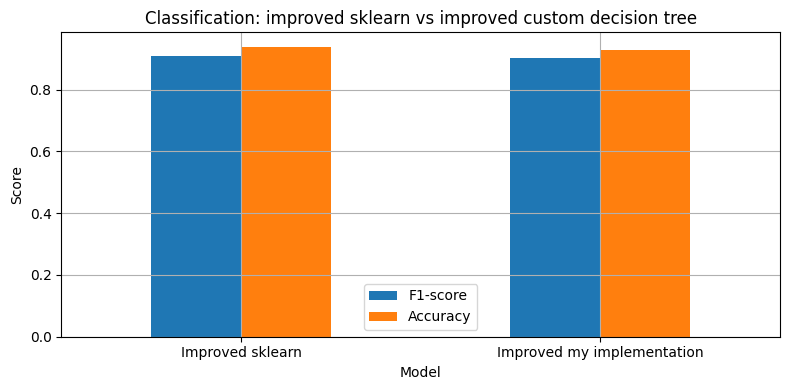

In [38]:
final_comparison_cls_plot = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "F1-score": [f1_improved, my_f1_improved],
    "Accuracy": [acc_improved, my_acc_improved]
})

final_comparison_cls_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Classification: improved sklearn vs improved custom decision tree")
plt.ylabel("Score")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


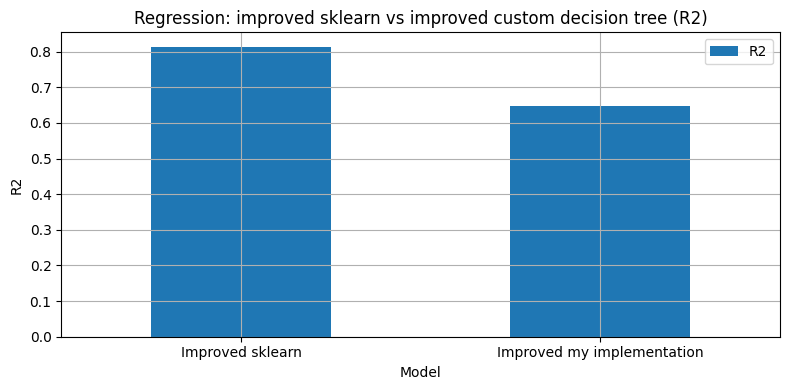

In [39]:
final_comparison_reg_r2_plot = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "R2": [r2_improved, my_r2_improved]
})

final_comparison_reg_r2_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: improved sklearn vs improved custom decision tree (R2)")
plt.ylabel("R2")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


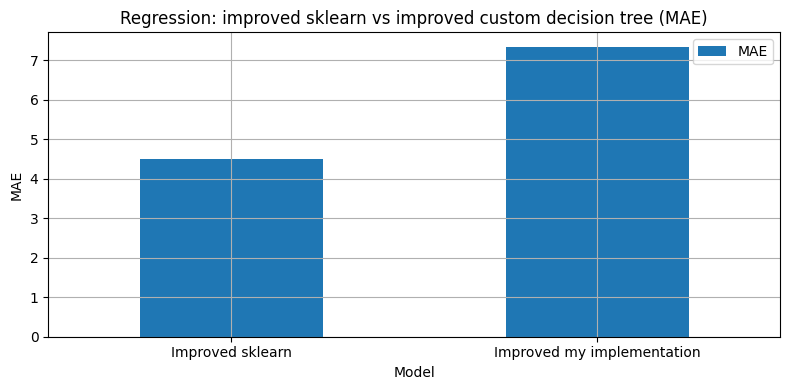

In [40]:
final_comparison_reg_mae_plot = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "MAE": [mae_improved, my_mae_improved]
})

final_comparison_reg_mae_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: improved sklearn vs improved custom decision tree (MAE)")
plt.ylabel("MAE")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Выводы

В ходе лабораторной работы были исследованы модели решающего дерева для задач классификации и регрессии. Были построены baseline-модели, сформулированы и проверены гипотезы по улучшению качества, подобраны гиперпараметры на кросс-валидации и получен improved baseline. Затем были реализованы собственные версии алгоритма решающего дерева для классификации и регрессии и проведено их сравнение с реализациями из sklearn.
